<a href="https://colab.research.google.com/github/Prathibha-bm/take_it_smart/blob/main/ML_Project_week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#Machine Learning Project Week8: HR Attrition Prediction (Classification)

#Problem statement

Employee attrition is a critical issue for organizations, leading to increased hiring costs, productivity loss, and reduced employee morale.In this project,the goal is to build a Machine Learning classification model that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:

● Age

● Salary

● Job Role

● Job Satisfaction

● Work Experience

● Overtime

● Work-Life Balance

● Department

#Objective
The objectives of this task is to:

● Understand and explore the HR dataset

● Perform data preprocessing (missing values, duplicates, outliers)

● Conduct Exploratory Data Analysis (EDA)

● Apply encoding and feature scaling

● Train multiple classification algorithms

● Evaluate models using classification metrics

● Perform cross-validation and hyperparameter tuning

● Select the best-performing model

#1. Import Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 2. Load the Dataset

In [264]:
df = pd.read_csv("/content/HR-Employee-Attrition.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


#3. Check Dataset

● Shape

● Columns

● Data types

● Summary statistics

In [ ]:
#shape
print("Shape:", df.shape)

Shape: (1470, 35)


In [ ]:
#columns
print("\nColumns:\n", df.columns)


Columns:
 Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [ ]:
#Datatypes
print("\nData Types:\n", df.dtypes)


Data Types:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalW

In [ ]:
#summary statistics
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# 4.Handle Missing Values

In [ ]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# 5. Remove Duplicate Records

In [ ]:
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)

After removing duplicates: (1470, 35)


# 6. Perform Univariate Analysis

● Distribution of numerical features

● Count plots for categorical features

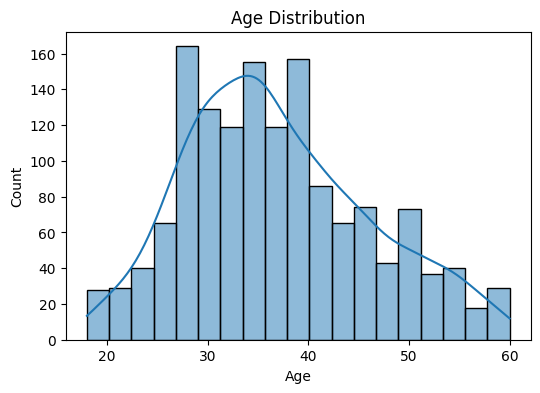

In [ ]:
#age distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

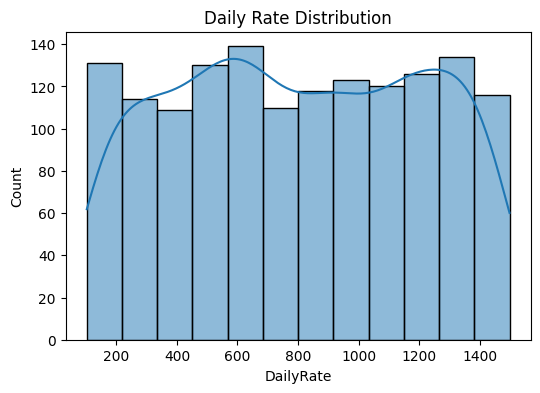

In [ ]:
#Daily rate distribution
plt.figure(figsize=(6,4))
sns.histplot(df['DailyRate'], kde=True)
plt.title("Daily Rate Distribution")
plt.show()

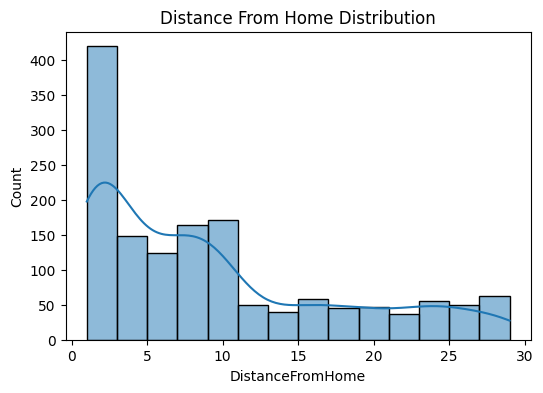

In [ ]:
#distance from home
plt.figure(figsize=(6,4))
sns.histplot(df['DistanceFromHome'], kde=True)
plt.title("Distance From Home Distribution")
plt.show()

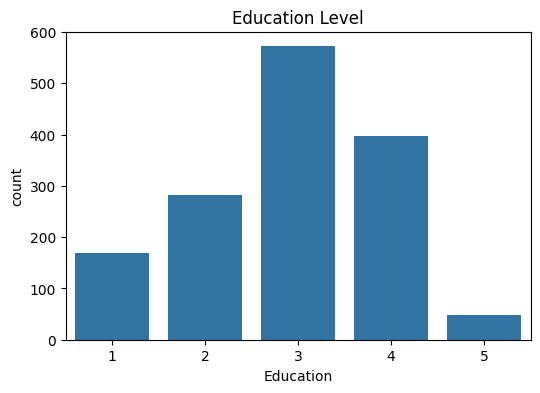

In [ ]:
#education
plt.figure(figsize=(6,4))
sns.countplot(x=df['Education'])
plt.title("Education Level")
plt.show()

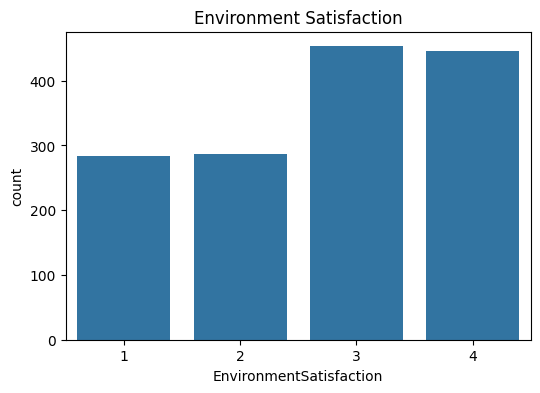

In [ ]:
#Environment Satisfaction
plt.figure(figsize=(6,4))
sns.countplot(x=df['EnvironmentSatisfaction'])
plt.title("Environment Satisfaction")
plt.show()

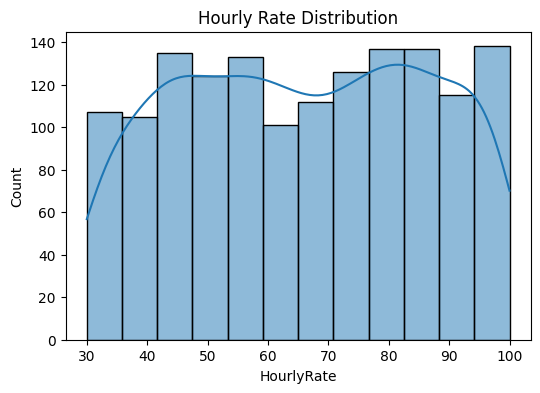

In [ ]:
#hourly rate
plt.figure(figsize=(6,4))
sns.histplot(df['HourlyRate'], kde=True)
plt.title("Hourly Rate Distribution")
plt.show()

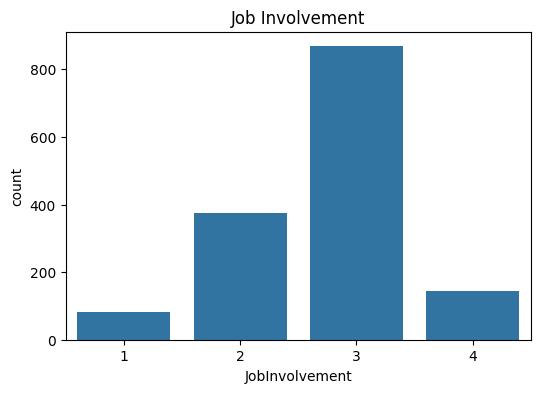

In [ ]:
#job involvement
plt.figure(figsize=(6,4))
sns.countplot(x=df['JobInvolvement'])
plt.title("Job Involvement")
plt.show()

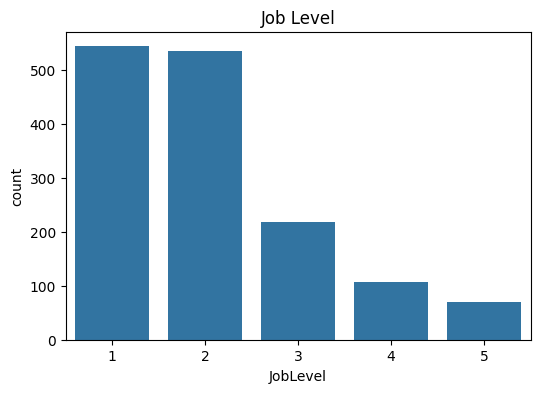

In [ ]:
#job level
plt.figure(figsize=(6,4))
sns.countplot(x=df['JobLevel'])
plt.title("Job Level")
plt.show()

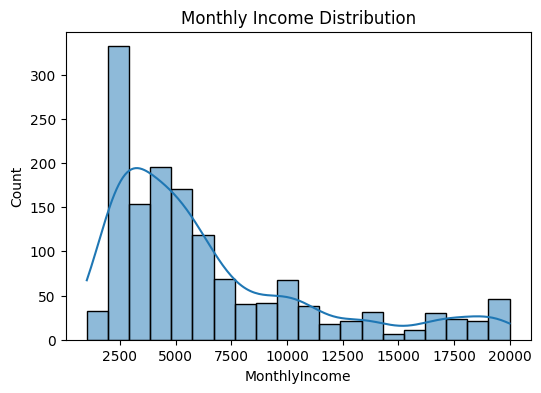

In [ ]:
#monthly income
plt.figure(figsize=(6,4))
sns.histplot(df['MonthlyIncome'], kde=True)
plt.title("Monthly Income Distribution")
plt.show()

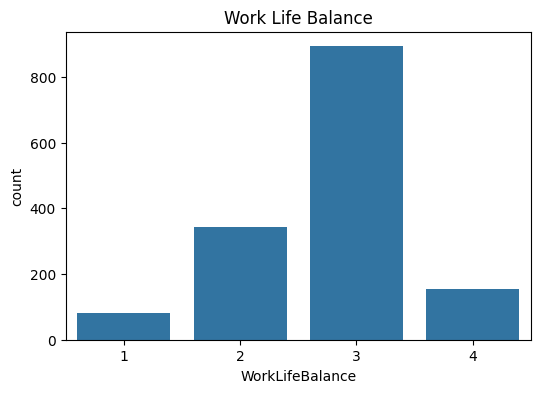

In [ ]:
#Work Life Balance
plt.figure(figsize=(6,4))
sns.countplot(x=df['WorkLifeBalance'])
plt.title("Work Life Balance")
plt.show()

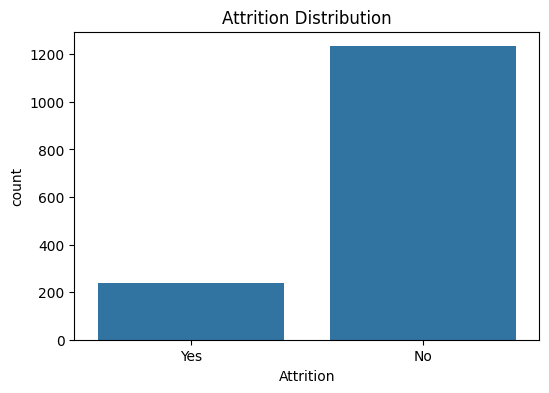

In [ ]:
#Attrition Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['Attrition'])
plt.title("Attrition Distribution")
plt.show()

# 7. Perform Bivariate Analysis

● Attrition vs categorical features

● Attrition vs numerical features

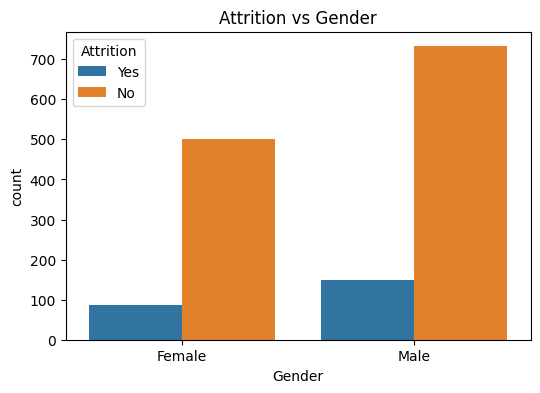

In [ ]:
#Attrition vs Gender
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', hue='Attrition', data=df)
plt.title("Attrition vs Gender")
plt.show()

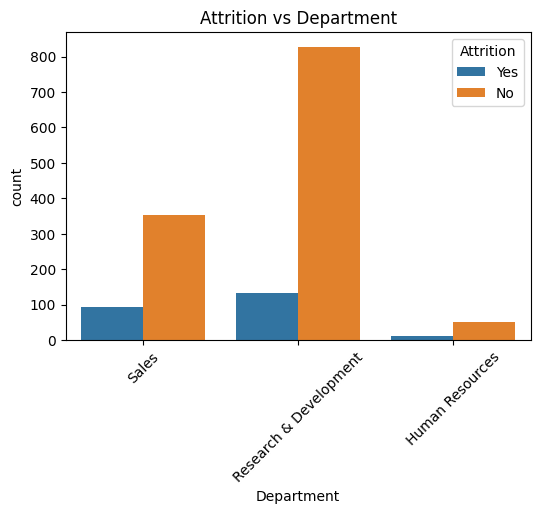

In [ ]:
#Attrition vs Department
plt.figure(figsize=(6,4))
sns.countplot(x='Department', hue='Attrition', data=df)
plt.xticks(rotation=45)
plt.title("Attrition vs Department")
plt.show()

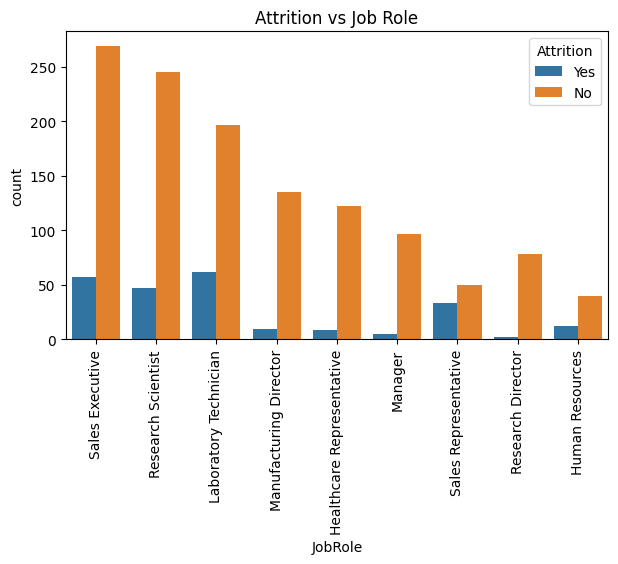

In [ ]:
#Attrition vs Job Role
plt.figure(figsize=(7,4))
sns.countplot(x='JobRole', hue='Attrition', data=df)
plt.xticks(rotation=90)
plt.title("Attrition vs Job Role")
plt.show()

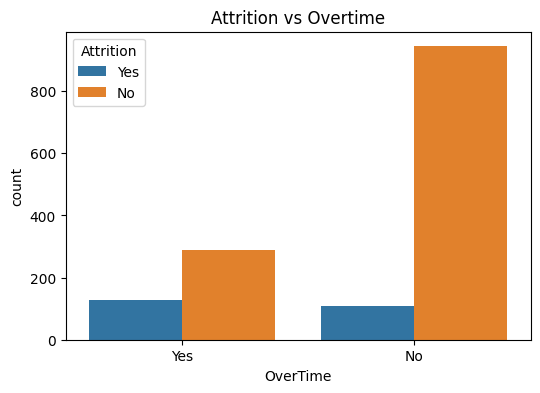

In [ ]:
#Attrition vs Overtime
plt.figure(figsize=(6,4))
sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title("Attrition vs Overtime")
plt.show()

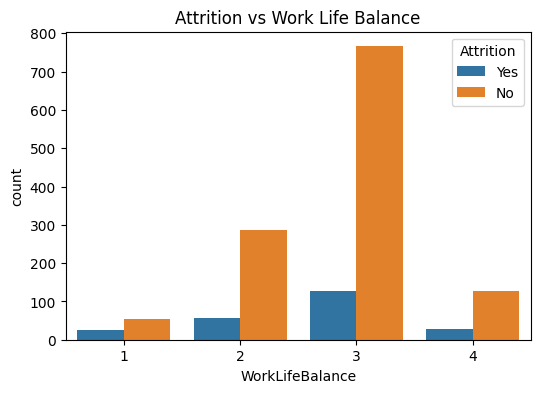

In [ ]:
#Attrition vs Work Life Balance
plt.figure(figsize=(6,4))
sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)
plt.title("Attrition vs Work Life Balance")
plt.show()

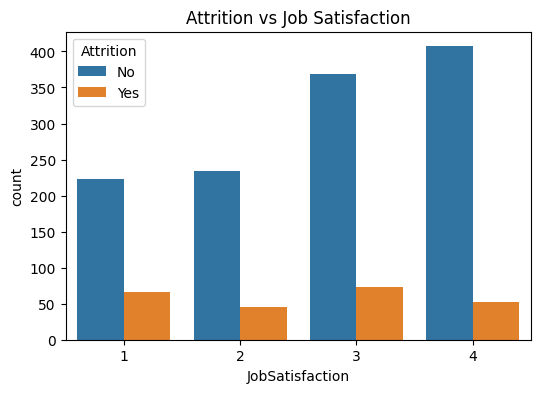

In [ ]:
#Attrition vs Job Satisfaction
plt.figure(figsize=(6,4))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)
plt.title("Attrition vs Job Satisfaction")
plt.show()

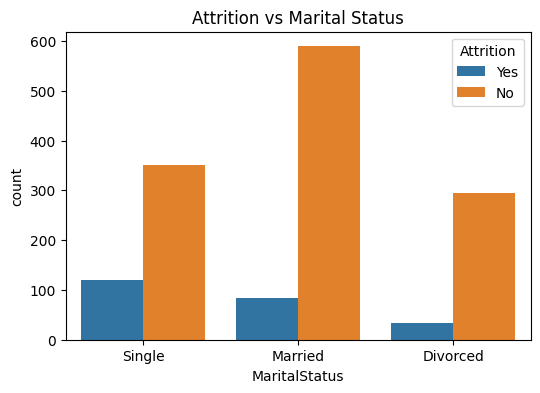

In [ ]:
#Attrition vs Marital Status
plt.figure(figsize=(6,4))
sns.countplot(x='MaritalStatus', hue='Attrition', data=df)
plt.title("Attrition vs Marital Status")
plt.show()

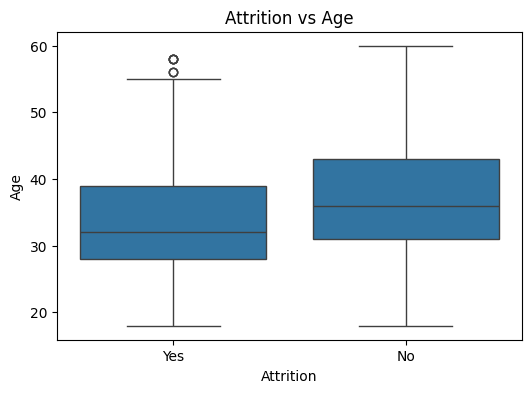

In [ ]:
#Attrition vs Age
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='Age', data=df)
plt.title("Attrition vs Age")
plt.show()

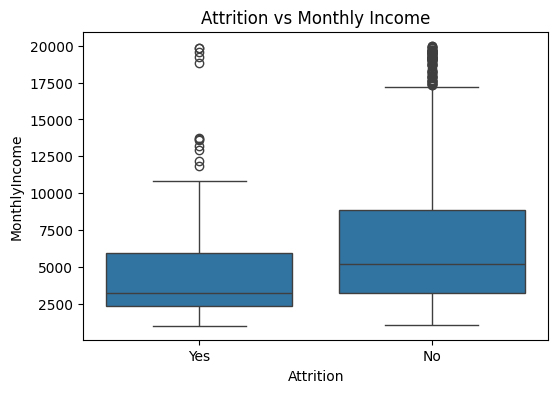

In [ ]:
#Attrition vs Monthly Income
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

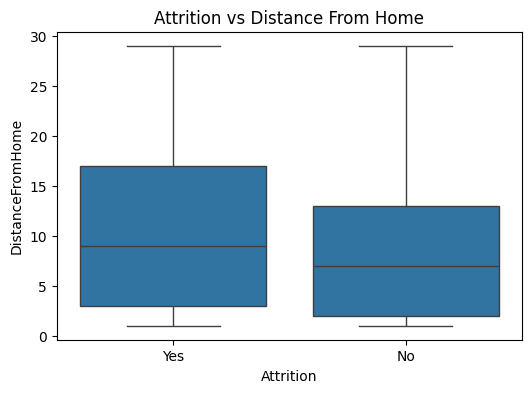

In [ ]:
#Attrition vs Distance From Home
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='DistanceFromHome', data=df)
plt.title("Attrition vs Distance From Home")
plt.show()

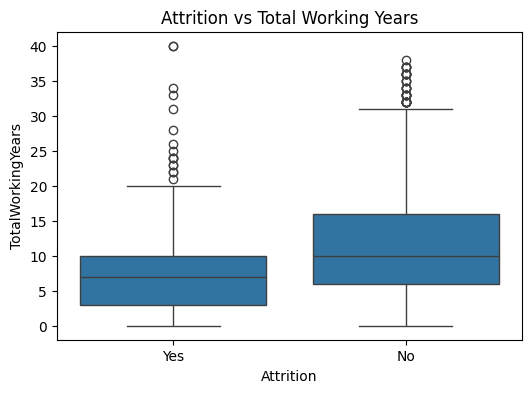

In [ ]:
#Attrition vs Total Working Years
plt.figure(figsize=(6,4))
sns.boxplot(x='Attrition', y='TotalWorkingYears', data=df)
plt.title("Attrition vs Total Working Years")
plt.show()

#8. Generate Correlation Heatmap

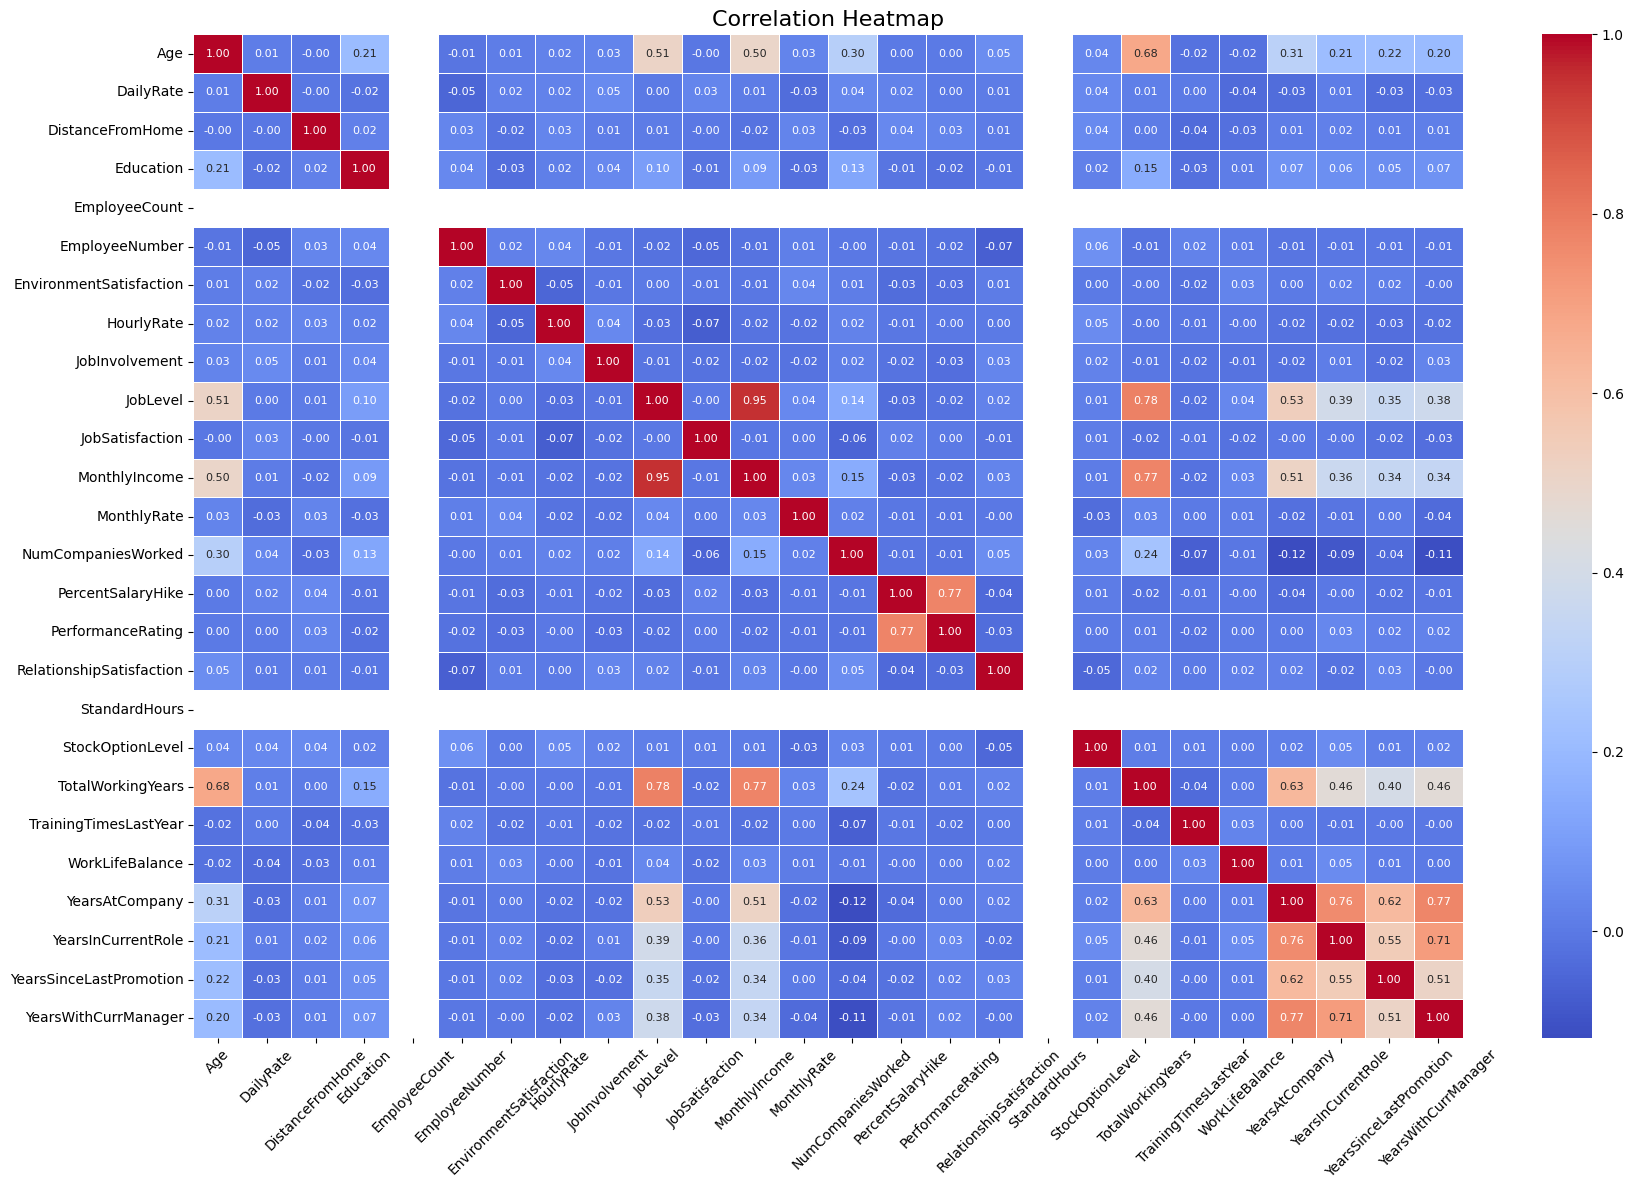

In [ ]:
plt.figure(figsize=(18,12))
numeric_df = df.select_dtypes(include=['int64','float64'])
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={"size":8}
)
plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

#9. Detect and Handle Outliers

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

# 10. Apply Encoding

● Label Encoding

● One-Hot Encoding

In [ ]:
# Check categorical columns
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
#Labbel encoding
le = LabelEncoder()
binary_cols = ['Attrition','OverTime','Gender']
for col in binary_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
5,32,0,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
11,29,0,Travel_Rarely,153,Research & Development,15,2,Life Sciences,1,15,...,4,80,0,10,3,3,9,5,0,8
12,31,0,Travel_Rarely,670,Research & Development,26,1,Life Sciences,1,16,...,4,80,1,5,1,2,5,2,4,3


In [ ]:
#one hot encoding
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)
df = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)


Index([], dtype='object')
Index([], dtype='object')


#11. Apply Scaling

● StandardScaler / MinMaxScaler

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

#12. Separate Features and Target Variable

● X → Features

● y → Attrition

In [ ]:
X = df.drop('Attrition', axis=1)#feature
y = df['Attrition']#target

#13. Perform Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#14. Balance data : SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np

# y_trainmust be integer (required for SMOTE)
y_train = y_train.astype(int)

#SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Verify the result
print("Class distribution after SMOTE:", np.bincount(y_train_res))

Class distribution after SMOTE: [460   0 460]


#15. Train Classification Models and Evaluation and confusion matrix

● Logistic Regression

● Decision Tree Classifier

● Random Forest Classifier

● KNN Classifier

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

# Convert y_test to 1D if one-hot encoded
if y_test.ndim == 2 and y_test.shape[1] > 1:
    y_test_labels = np.argmax(y_test, axis=1)
else:
    y_test_labels = y_test.astype(int)

y_train_labels = y_train.astype(int)  # training labels

# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train_labels)

# Predictions
y_pred_log = log_model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test_labels, y_pred_log)
precision = precision_score(y_test_labels, y_pred_log, average='weighted')
recall = recall_score(y_test_labels, y_pred_log, average='weighted')
f1 = f1_score(y_test_labels, y_pred_log, average='weighted')
log_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])
cm = confusion_matrix(y_test_labels, y_pred_log)

# Display
print("Logistic Regression Results")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("ROC-AUC:", log_auc)
print("Confusion Matrix:\n", cm)

Logistic Regression Results
Accuracy: 0.8357142857142857
Precision: 0.8219555035128805
Recall: 0.8357142857142857
F1 Score: 0.8274153339262025
ROC-AUC: 0.7220364176885916
Confusion Matrix:
 [[108   9]
 [ 14   9]]


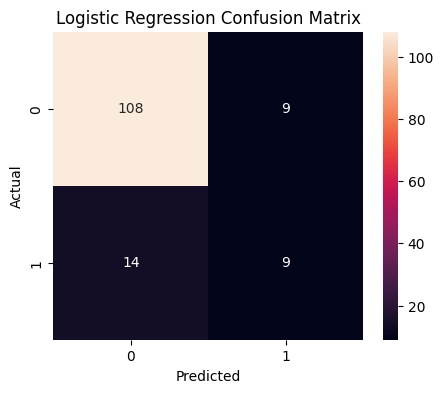

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Decision Tree Classifier
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

dt_precision = precision_score(y_test, y_pred_dt, pos_label=2)
dt_recall = recall_score(y_test, y_pred_dt, pos_label=2)
dt_f1 = f1_score(y_test, y_pred_dt, pos_label=2)

dt_auc = roc_auc_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1 Score:", dt_f1)
print("ROC-AUC:", dt_auc)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))



Decision Tree Results
Accuracy: 0.7642857142857142
Precision: 0.25
Recall: 0.21739130434782608
F1 Score: 0.23255813953488372
ROC-AUC: 0.544593088071349
Confusion Matrix:
 [[102  15]
 [ 18   5]]


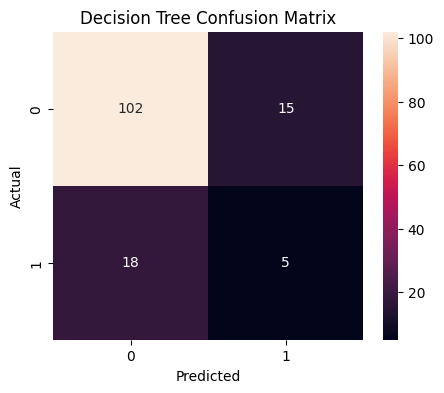

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(y_test, y_pred_rf, pos_label=2)
rf_recall = recall_score(y_test, y_pred_rf, pos_label=2)
rf_f1 = f1_score(y_test, y_pred_rf, pos_label=2)

rf_auc = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])

print("Random Forest Results")
print("Accuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("ROC-AUC:", rf_auc)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.8357142857142857
Precision: 0.5
Recall: 0.08695652173913043
F1 Score: 0.14814814814814814
ROC-AUC: 0.6854329245633594
Confusion Matrix:
 [[115   2]
 [ 21   2]]


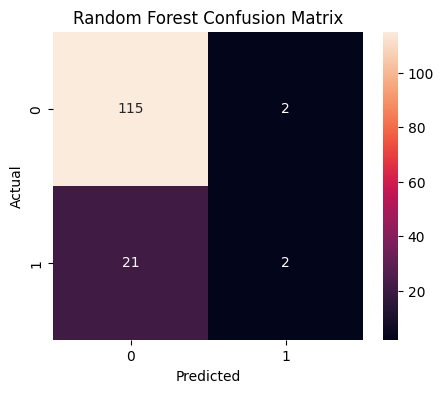

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# KNN Classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)

y_pred_knn = knn_model.predict(X_test)

# Basic Accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

# Fixed Metrics - we must use pos_label=2 for all of these
knn_precision = precision_score(y_test, y_pred_knn, pos_label=2)
knn_recall = recall_score(y_test, y_pred_knn, pos_label=2)
knn_f1 = f1_score(y_test, y_pred_knn, pos_label=2)

# For ROC-AUC, always use predict_proba for better precision
knn_auc = roc_auc_score(y_test, knn_model.predict_proba(X_test)[:, 1])

print("KNN Results")
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1 Score:", knn_f1)
print("ROC-AUC:", knn_auc)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

KNN Results
Accuracy: 0.8357142857142857
Precision: 0.5
Recall: 0.08695652173913043
F1 Score: 0.14814814814814814
ROC-AUC: 0.5880713489409142
Confusion Matrix:
 [[115   2]
 [ 21   2]]


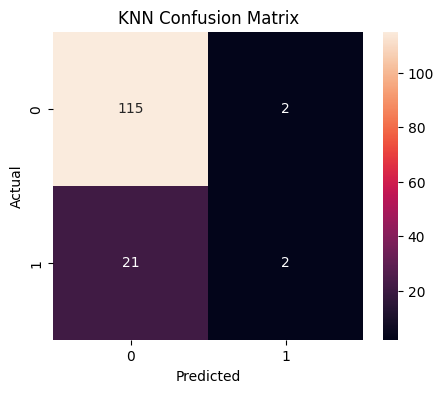

In [ ]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 17. Perform Cross Validation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

#18. Apply Hyperparameter Tuning

● GridSearchCV

● RandomizedSearchCV

In [ ]:
#Logistic Regression — GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

param_grid = {
    'C':[0.01,0.1,1,10],
    'solver':['liblinear','lbfgs']
}
grid_log = GridSearchCV(log_model, param_grid, cv=5)

grid_log.fit(X_train, y_train)

print("Best Parameters:", grid_log.best_params_)
print("Best Score:", grid_log.best_score_)

Best Parameters: {'C': 0.1, 'solver': 'liblinear'}
Best Score: 0.8765604890604891


In [ ]:
#Decision Tree — GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()

param_grid = {
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'criterion':['gini','entropy']
}

grid_dt = GridSearchCV(dt_model, param_grid, cv=5)

grid_dt.fit(X_train, y_train)

print("Best Parameters:", grid_dt.best_params_)
print("Best Score:", grid_dt.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2}
Best Score: 0.8211550836550836


In [ ]:
#Random Forest — GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[None,5,10],
    'min_samples_split':[2,5]
}
grid_rf = GridSearchCV(rf_model, param_grid, cv=5)

grid_rf.fit(X_train, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best Score: 0.8461711711711711


In [ ]:
#KNN — GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier()
param_grid = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}
grid_knn = GridSearchCV(knn_model, param_grid, cv=5)

grid_knn.fit(X_train, y_train)

print("Best Parameters:", grid_knn.best_params_)
print("Best Score:", grid_knn.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best Score: 0.8497908622908623


#RANDOMIZEDSEARCHCV

In [ ]:
#Decision Tree
param_dt = {
    'max_depth':[3,5,10,None],
    'criterion':['gini','entropy']
}
rand_dt = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_dt,
    n_iter=10,
    cv=5,
    random_state=42
)
rand_dt.fit(X_train,y_train)

print(rand_dt.best_params_)
print(rand_dt.best_score_)

{'max_depth': 3, 'criterion': 'entropy'}
0.8211550836550836


In [ ]:
#random forest
param_rf = {
    'n_estimators':[100,200],
    'max_depth':[None,5,10]
}

rand_rf = RandomizedSearchCV(
    RandomForestClassifier(),
    param_rf,
    n_iter=10,
    cv=5,
    random_state=42
)

rand_rf.fit(X_train,y_train)

print(rand_rf.best_params_)

print(rand_rf.best_score_)

{'n_estimators': 200, 'max_depth': None}
0.8461872586872587


In [ ]:
#knn
param_knn = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan']
}

rand_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_knn,
    n_iter=10,
    cv=5,
    random_state=42
)
rand_knn.fit(X_train,y_train)
print(rand_knn.best_params_)
print(rand_knn.best_score_)

{'weights': 'distance', 'n_neighbors': 7, 'metric': 'manhattan'}
0.8497908622908623


#19.Compare Models

In [ ]:
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'SVM'],
    'Accuracy': [0.85, 0.90, 0.88],
    'F1_Score': [0.83, 0.91, 0.87]
}
results_df = pd.DataFrame(results).T
print(results_df)

                            0              1     2
Model     Logistic Regression  Random Forest   SVM
Accuracy                 0.85            0.9  0.88
F1_Score                 0.83           0.91  0.87


In [ ]:
import pandas as pd
data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN'],
    'Accuracy': [log_accuracy, dt_accuracy, rf_accuracy, knn_accuracy],
    'Precision': [log_precision, dt_precision, rf_precision, knn_precision],
    'Recall': [log_recall, dt_recall, rf_recall, knn_recall]
}
results_df = pd.DataFrame(data)
results_df.set_index('Model', inplace=True)

print(results_df)

best_model_name = results_df['Accuracy'].idxmax()
print("\nBest Model based on Accuracy:", best_model_name)

                     Accuracy  Precision    Recall
Model                                             
Logistic Regression  0.835714   0.821956  0.835714
Decision Tree        0.764286   0.250000  0.217391
Random Forest        0.835714   0.500000  0.086957
KNN                  0.835714   0.500000  0.086957

Best Model based on Accuracy: Logistic Regression


#Insights

1.**The Problem:**
Logistic Regression, Random Forest, and KNN all show 83.6% accuracy, but this is misleading. In an imbalanced dataset where most people stay, the models are simply "guessing" the majority class.

**The Proof:** Random Forest and KNN have a Recall of 0.086, meaning they miss 91% of employees who actually leave.


**The Winner:** Logistic Regression is the best model because it maintains the best balance between Precision and Recall, actually identifying at-risk employees rather than just playing it safe.



2.**Key Attrition Drivers (EDA)**

**Overtime:** Working extra hours is the strongest predictor of burnout and resignation.


**Income & Age:** Younger employees and those in lower salary brackets have significantly higher turnover rates.


**Business Impact:** To reduce costs, HR should prioritize Recall (finding everyone who might leave) over simple Accuracy. This allows for proactive intervention in high-risk groups (low income + high overtime).